# Fraud Detection

In [ ]:
 '''
================================================================================
********************************  Columns Info  ********************************
================================================================================



**********  Əməliyyat göstəriciləri  *************
--------------------------------------------------------------------------------
transaction_amount — əməliyyatın məbləği.
transaction_type — əməliyyatın növü (məs., nağdsız, onlayn, POS və s.).
transaction_channel — əməliyyatın kanalı (mobil, web, ATM və s.).
transaction_hour — əməliyyatın baş verdiyi saat.
transaction_day_of_week — əməliyyatın aid olduğu həftə günü.
transaction_country — əməliyyatın icra edildiyi ölkə.
transaction_currency — əməliyyat valyutası.
merchant_category — satıcı və ya xidmət kateqoriyası.
merchant_risk_score — satıcı ilə bağlı risk balı.
card_type — istifadə olunan kart növü (debet, kredit və s.).
card_present_flag — kartın əməliyyat zamanı fiziki olaraq mövcud olub-olmaması.
cross_border_flag — əməliyyatın ölkələrarası olub-olmaması.
ip_address_region — əməliyyatda istifadə olunan IP regionu.
device_trust_score — istifadə olunan cihazın etibarlılıq balı.
--------------------------------------------------------------------------------


**********  Müştəri profili  *************
--------------------------------------------------------------------------------
age — müştərinin yaşı.
gender — müştərinin cinsi.
region — müştərinin yaşadığı region.
account_tenure_days — hesabın aktiv olduğu gün sayı.
account_type — hesabın növü (fərdi, korporativ və s.).
avg_monthly_balance — hesabın orta aylıq balansı.
total_loans — müştərinin mövcud kreditlərinin sayı və ya həcmi.
credit_score — kredit reytinq balı.
loyalty_score — bankla əməkdaşlıq sədaqət balı.
risk_profile — müştərinin ümumi risk profili.
--------------------------------------------------------------------------------


**********  Risk & Təhlükəsizlik  *************
--------------------------------------------------------------------------------
blacklist_flag — müştəri və ya cihazın qara siyahıda olub-olmaması.
aml_alert_flag — AML sistemi tərəfindən şübhəli əməliyyat xəbərdarlığı.
suspicious_device_flag — şübhəli cihazdan istifadə indikatoru.
suspicious_ip_flag — şübhəli IP ünvanından istifadə indikatoru.
chargeback_count_12m — son 12 ayda geri ödəniş (chargeback) sayı.
previous_fraud_flag — keçmişdə fraud hadisəsi olub-olmaması.
support_tickets_6m — son 6 ayda dəstək müraciətləri sayı.
internal_risk_score — daxili sistem üzrə risk balı.
external_risk_score — xarici reytinq mənbələrindən risk balı.
compliance_score — uyğunsuzluq və tənzimləmə uyğunluğu balı.
--------------------------------------------------------------------------------


**********  Engineered Features  *************
--------------------------------------------------------------------------------
velocity_score — əməliyyatların sürət və tezlik göstəricisi.
amount_to_balance_ratio — əməliyyat məbləğinin balansla nisbəti.
suspicious_behavior_score — davranış üzrə avtomatik risk balı.
--------------------------------------------------------------------------------


**********  Target sütunları  *************
--------------------------------------------------------------------------------
fraud_flag — əməliyyatın fraud (1) və ya normal (0) olması.
fraud_probability — əməliyyatın fraud olma ehtimalı (0–1 arası).
--------------------------------------------------------------------------------

'''

'\n================================================================================\n********************************  Columns Info  ********************************\n================================================================================\n\n\n\n**********  Əməliyyat göstəriciləri  *************\n--------------------------------------------------------------------------------\ntransaction_amount — əməliyyatın məbləği.\ntransaction_type — əməliyyatın növü (məs., nağdsız, onlayn, POS və s.).\ntransaction_channel — əməliyyatın kanalı (mobil, web, ATM və s.).\ntransaction_hour — əməliyyatın baş verdiyi saat.\ntransaction_day_of_week — əməliyyatın aid olduğu həftə günü.\ntransaction_country — əməliyyatın icra edildiyi ölkə.\ntransaction_currency — əməliyyat valyutası.\nmerchant_category — satıcı və ya xidmət kateqoriyası.\nmerchant_risk_score — satıcı ilə bağlı risk balı.\ncard_type — istifadə olunan kart növü (debet, kredit və s.).\ncard_present_flag — kartın əməliyyat zamanı fizi

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder

pd.set_option('display.max_columns', None)

In [2]:
from google.colab import files
uploaded = files.upload()

Saving 06. Fraud_detection_dataset.xlsx to 06. Fraud_detection_dataset.xlsx


In [ ]:
df = pd.read_excel('/content/06. Fraud_detection_dataset.xlsx')
df.head()

,transaction_amount,transaction_type,transaction_channel,transaction_hour,transaction_day_of_week,transaction_country,transaction_currency,merchant_category,merchant_risk_score,card_type,card_present_flag,cross_border_flag,ip_address_region,device_trust_score,age,gender,region,account_tenure_days,account_type,avg_monthly_balance,total_loans,credit_score,loyalty_score,risk_profile,transactions_last_24h,transactions_last_7d,transactions_last_30d,avg_transaction_amount_7d,avg_transaction_amount_30d,failed_login_attempts_24h,device_change_30d,ip_change_30d,mobile_app_logins_30d,web_logins_30d,branch_visits_30d,blacklist_flag,aml_alert_flag,suspicious_device_flag,suspicious_ip_flag,chargeback_count_12m,previous_fraud_flag,support_tickets_6m,internal_risk_score,external_risk_score,compliance_score,velocity_score,amount_to_balance_ratio,suspicious_behavior_score,fraud_flag,fraud_probability
0,1873.326054,ATM,Web,17.0,Thu,TR,NaN,Travel,NaN,Credit,1.0,0.0,Foreign,24.0,50.0,Male,Rural,4657.0,Business,96285.364820,7.0,609.0,93.0,Medium,26.0,85.0,248.0,250.246868,1848.669085,1.0,2.0,2.0,96.0,179.0,6.0,0.0,0.0,0.0,0.0,6.0,0.0,0.0,67.0,4.0,36.0,0.915368,1.435066,0.964333,0,0.370924
1,4753.620818,Wire,Mobile,15.0,Fri,NaN,AZN,Restaurant,86.0,Credit,0.0,0.0,Local,47.0,68.0,Female,Urban,NaN,Business,81536.471290,5.0,696.0,96.0,Medium,14.0,14.0,0.0,NaN,256.357273,8.0,2.0,0.0,102.0,73.0,NaN,0.0,0.0,0.0,1.0,6.0,0.0,19.0,71.0,99.0,41.0,0.813364,1.311163,0.553211,1,0.496739
2,3660.237715,ATM,Mobile,16.0,Thu,TR,GBP,Travel,28.0,Debit,0.0,0.0,Local,72.0,46.0,Male,Urban,1775.0,Savings,69498.434019,3.0,805.0,9.0,NaN,7.0,22.0,296.0,108.521907,1233.907622,6.0,0.0,4.0,2.0,42.0,7.0,0.0,0.0,1.0,1.0,0.0,0.0,15.0,34.0,79.0,0.0,0.939946,0.672257,0.287086,1,0.456115
3,2993.693763,Wire,Mobile,6.0,Mon,AZ,USD,NaN,40.0,Debit,NaN,1.0,Foreign,60.0,48.0,Male,Urban,4104.0,Savings,55005.947033,4.0,794.0,NaN,High,15.0,12.0,23.0,818.759024,2122.654157,4.0,4.0,0.0,115.0,NaN,18.0,0.0,1.0,0.0,0.0,6.0,0.0,12.0,93.0,80.0,8.0,0.340578,1.596243,0.386247,1,0.433529
4,780.937184,Wire,Mobile,11.0,Wed,US,EUR,NaN,NaN,Credit,0.0,0.0,Local,34.0,61.0,Female,Rural,2535.0,Savings,92081.748823,1.0,343.0,57.0,Low,7.0,21.0,NaN,1485.509646,2907.076786,4.0,1.0,1.0,17.0,100.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,31.0,11.0,27.0,0.990250,1.235550,0.810898,0,0.340988


In [ ]:
df.shape

(5000, 50)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 50 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   transaction_amount          4750 non-null   float64
 1   transaction_type            4750 non-null   object 
 2   transaction_channel         4750 non-null   object 
 3   transaction_hour            4750 non-null   float64
 4   transaction_day_of_week     4750 non-null   object 
 5   transaction_country         4750 non-null   object 
 6   transaction_currency        4750 non-null   object 
 7   merchant_category           4750 non-null   object 
 8   merchant_risk_score         4750 non-null   float64
 9   card_type                   4750 non-null   object 
 10  card_present_flag           4750 non-null   float64
 11  cross_border_flag           4750 non-null   float64
 12  ip_address_region           4750 non-null   object 
 13  device_trust_score          4750 

In [ ]:
df.isnull().sum()

,0
transaction_amount,250
transaction_type,250
transaction_channel,250
transaction_hour,250
transaction_day_of_week,250
transaction_country,250
transaction_currency,250
merchant_category,250
merchant_risk_score,250
card_type,250


In [ ]:
df[df.isna().any(axis=1)].head()

,transaction_amount,transaction_type,transaction_channel,transaction_hour,transaction_day_of_week,transaction_country,transaction_currency,merchant_category,merchant_risk_score,card_type,card_present_flag,cross_border_flag,ip_address_region,device_trust_score,age,gender,region,account_tenure_days,account_type,avg_monthly_balance,total_loans,credit_score,loyalty_score,risk_profile,transactions_last_24h,transactions_last_7d,transactions_last_30d,avg_transaction_amount_7d,avg_transaction_amount_30d,failed_login_attempts_24h,device_change_30d,ip_change_30d,mobile_app_logins_30d,web_logins_30d,branch_visits_30d,blacklist_flag,aml_alert_flag,suspicious_device_flag,suspicious_ip_flag,chargeback_count_12m,previous_fraud_flag,support_tickets_6m,internal_risk_score,external_risk_score,compliance_score,velocity_score,amount_to_balance_ratio,suspicious_behavior_score,fraud_flag,fraud_probability
0,1873.326054,ATM,Web,17.0,Thu,TR,NaN,Travel,NaN,Credit,1.0,0.0,Foreign,24.0,50.0,Male,Rural,4657.0,Business,96285.364820,7.0,609.0,93.0,Medium,26.0,85.0,248.0,250.246868,1848.669085,1.0,2.0,2.0,96.0,179.0,6.0,0.0,0.0,0.0,0.0,6.0,0.0,0.0,67.0,4.0,36.0,0.915368,1.435066,0.964333,0,0.370924
1,4753.620818,Wire,Mobile,15.0,Fri,NaN,AZN,Restaurant,86.0,Credit,0.0,0.0,Local,47.0,68.0,Female,Urban,NaN,Business,81536.471290,5.0,696.0,96.0,Medium,14.0,14.0,0.0,NaN,256.357273,8.0,2.0,0.0,102.0,73.0,NaN,0.0,0.0,0.0,1.0,6.0,0.0,19.0,71.0,99.0,41.0,0.813364,1.311163,0.553211,1,0.496739
2,3660.237715,ATM,Mobile,16.0,Thu,TR,GBP,Travel,28.0,Debit,0.0,0.0,Local,72.0,46.0,Male,Urban,1775.0,Savings,69498.434019,3.0,805.0,9.0,NaN,7.0,22.0,296.0,108.521907,1233.907622,6.0,0.0,4.0,2.0,42.0,7.0,0.0,0.0,1.0,1.0,0.0,0.0,15.0,34.0,79.0,0.0,0.939946,0.672257,0.287086,1,0.456115
3,2993.693763,Wire,Mobile,6.0,Mon,AZ,USD,NaN,40.0,Debit,NaN,1.0,Foreign,60.0,48.0,Male,Urban,4104.0,Savings,55005.947033,4.0,794.0,NaN,High,15.0,12.0,23.0,818.759024,2122.654157,4.0,4.0,0.0,115.0,NaN,18.0,0.0,1.0,0.0,0.0,6.0,0.0,12.0,93.0,80.0,8.0,0.340578,1.596243,0.386247,1,0.433529
4,780.937184,Wire,Mobile,11.0,Wed,US,EUR,NaN,NaN,Credit,0.0,0.0,Local,34.0,61.0,Female,Rural,2535.0,Savings,92081.748823,1.0,343.0,57.0,Low,7.0,21.0,NaN,1485.509646,2907.076786,4.0,1.0,1.0,17.0,100.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,31.0,11.0,27.0,0.990250,1.235550,0.810898,0,0.340988


In [ ]:
df.describe()

,transaction_amount,transaction_hour,merchant_risk_score,card_present_flag,cross_border_flag,device_trust_score,age,account_tenure_days,avg_monthly_balance,total_loans,credit_score,loyalty_score,transactions_last_24h,transactions_last_7d,transactions_last_30d,avg_transaction_amount_7d,avg_transaction_amount_30d,failed_login_attempts_24h,device_change_30d,ip_change_30d,mobile_app_logins_30d,web_logins_30d,branch_visits_30d,blacklist_flag,aml_alert_flag,suspicious_device_flag,suspicious_ip_flag,chargeback_count_12m,previous_fraud_flag,support_tickets_6m,internal_risk_score,external_risk_score,compliance_score,velocity_score,amount_to_balance_ratio,suspicious_behavior_score,fraud_flag,fraud_probability
count,4750.000000,4750.000000,4750.000000,4750.000000,4750.000000,4750.000000,4750.000000,4750.000000,4750.000000,4750.000000,4750.000000,4750.000000,4750.000000,4750.000000,4750.0000,4750.000000,4750.000000,4750.000000,4750.000000,4750.000000,4750.000000,4750.000000,4750.000000,4750.000000,4750.000000,4750.000000,4750.000000,4750.000000,4750.000000,4750.000000,4750.000000,4750.000000,4750.000000,4750.000000,4750.000000,4750.000000,5000.000000,5000.000000
mean,2486.774191,11.620211,49.602947,0.192421,0.116421,49.212632,48.592842,2526.210737,50420.604586,4.487579,576.486737,48.684211,14.480632,49.873263,150.4000,1002.984655,1502.845437,4.517895,1.998737,2.001263,74.389263,100.550737,9.400421,0.058316,0.030316,0.103789,0.086947,4.458105,0.021053,9.522105,50.368632,49.109684,49.171158,0.503464,1.002190,0.495512,0.553800,0.371045
std,1446.801237,6.939999,28.636610,0.394243,0.320763,28.898779,17.679921,1438.859640,29028.384679,2.907385,158.199100,28.872336,8.667748,28.753231,86.5519,579.357015,868.012033,2.866731,1.416891,1.404052,42.747830,58.302443,5.770956,0.234364,0.171473,0.305019,0.281788,2.867949,0.143575,5.739652,28.629375,28.758409,28.791924,0.289094,0.574175,0.287198,0.497147,0.048291
min,1.058162,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000,30.000000,11.510926,0.000000,300.000000,0.000000,0.000000,0.000000,0.0000,1.661861,1.686471,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000031,0.000697,0.000259,0.000000,0.233990
25%,1227.504204,6.000000,25.000000,0.000000,0.000000,24.000000,34.000000,1279.000000,25260.574368,2.000000,440.250000,24.000000,7.000000,25.000000,76.0000,496.656127,729.012785,2.000000,1.000000,1.000000,38.000000,50.000000,4.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,5.000000,26.000000,25.000000,25.000000,0.255614,0.500678,0.246752,0.000000,0.337599
50%,2501.478023,12.000000,50.000000,0.000000,0.000000,49.000000,49.000000,2525.500000,50334.090610,5.000000,578.000000,48.000000,15.000000,50.000000,150.0000,1012.504974,1525.198147,5.000000,2.000000,2.000000,74.000000,101.000000,9.000000,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000,10.000000,51.000000,49.000000,48.000000,0.513516,1.012559,0.492103,1.000000,0.370292
75%,3732.152489,18.000000,74.000000,0.000000,0.000000,75.000000,64.000000,3791.750000,76372.640732,7.000000,716.000000,74.000000,22.000000,75.000000,227.0000,1499.855894,2242.446185,7.000000,3.000000,3.000000,111.000000,152.000000,14.000000,0.000000,0.000000,0.000000,0.000000,7.000000,0.000000,14.000000,75.000000,74.000000,74.000000,0.755092,1.487039,0.741705,1.000000,0.403302
max,4998.588649,23.000000,99.000000,1.000000,1.000000,99.000000,79.000000,4996.000000,99967.664876,9.000000,849.000000,99.000000,29.000000,99.000000,299.0000,1999.795940,2999.750942,9.000000,4.000000,4.000000,149.000000,199.000000,19.000000,1.000000,1.000000,1.000000,1.000000,9.000000,1.000000,19.000000,99.000000,99.000000,99.000000,0.999843,1.999763,0.999846,1.000000,0.532174


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.head()

,transaction_amount,transaction_type,transaction_channel,transaction_hour,transaction_day_of_week,transaction_country,transaction_currency,merchant_category,merchant_risk_score,card_type,card_present_flag,cross_border_flag,ip_address_region,device_trust_score,age,gender,region,account_tenure_days,account_type,avg_monthly_balance,total_loans,credit_score,loyalty_score,risk_profile,transactions_last_24h,transactions_last_7d,transactions_last_30d,avg_transaction_amount_7d,avg_transaction_amount_30d,failed_login_attempts_24h,device_change_30d,ip_change_30d,mobile_app_logins_30d,web_logins_30d,branch_visits_30d,blacklist_flag,aml_alert_flag,suspicious_device_flag,suspicious_ip_flag,chargeback_count_12m,previous_fraud_flag,support_tickets_6m,internal_risk_score,external_risk_score,compliance_score,velocity_score,amount_to_balance_ratio,suspicious_behavior_score,fraud_flag,fraud_probability
0,1873.326054,ATM,Web,17.0,Thu,TR,NaN,Travel,NaN,Credit,1.0,0.0,Foreign,24.0,50.0,Male,Rural,4657.0,Business,96285.364820,7.0,609.0,93.0,Medium,26.0,85.0,248.0,250.246868,1848.669085,1.0,2.0,2.0,96.0,179.0,6.0,0.0,0.0,0.0,0.0,6.0,0.0,0.0,67.0,4.0,36.0,0.915368,1.435066,0.964333,0,0.370924
1,4753.620818,Wire,Mobile,15.0,Fri,NaN,AZN,Restaurant,86.0,Credit,0.0,0.0,Local,47.0,68.0,Female,Urban,NaN,Business,81536.471290,5.0,696.0,96.0,Medium,14.0,14.0,0.0,NaN,256.357273,8.0,2.0,0.0,102.0,73.0,NaN,0.0,0.0,0.0,1.0,6.0,0.0,19.0,71.0,99.0,41.0,0.813364,1.311163,0.553211,1,0.496739
2,3660.237715,ATM,Mobile,16.0,Thu,TR,GBP,Travel,28.0,Debit,0.0,0.0,Local,72.0,46.0,Male,Urban,1775.0,Savings,69498.434019,3.0,805.0,9.0,NaN,7.0,22.0,296.0,108.521907,1233.907622,6.0,0.0,4.0,2.0,42.0,7.0,0.0,0.0,1.0,1.0,0.0,0.0,15.0,34.0,79.0,0.0,0.939946,0.672257,0.287086,1,0.456115
3,2993.693763,Wire,Mobile,6.0,Mon,AZ,USD,NaN,40.0,Debit,NaN,1.0,Foreign,60.0,48.0,Male,Urban,4104.0,Savings,55005.947033,4.0,794.0,NaN,High,15.0,12.0,23.0,818.759024,2122.654157,4.0,4.0,0.0,115.0,NaN,18.0,0.0,1.0,0.0,0.0,6.0,0.0,12.0,93.0,80.0,8.0,0.340578,1.596243,0.386247,1,0.433529
4,780.937184,Wire,Mobile,11.0,Wed,US,EUR,NaN,NaN,Credit,0.0,0.0,Local,34.0,61.0,Female,Rural,2535.0,Savings,92081.748823,1.0,343.0,57.0,Low,7.0,21.0,NaN,1485.509646,2907.076786,4.0,1.0,1.0,17.0,100.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,31.0,11.0,27.0,0.990250,1.235550,0.810898,0,0.340988


## EDA

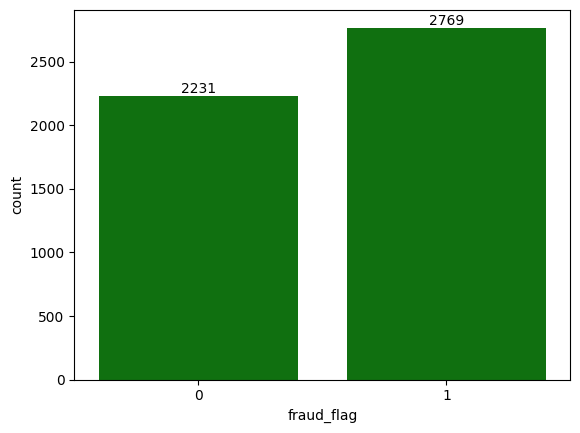

In [ ]:
ax = sns.countplot(data=df, x='fraud_flag',color='green')
ax.bar_label(ax.containers[0])

plt.show()

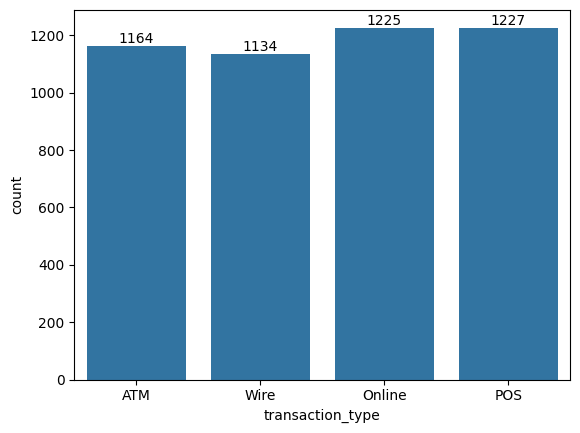

In [ ]:
ax = sns.countplot(data=df, x='transaction_type')
ax.bar_label(ax.containers[0])

plt.show()

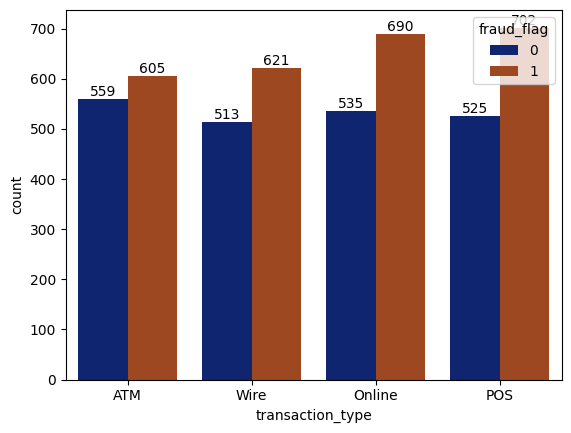

In [ ]:

ax = sns.countplot(data=df, x='transaction_type', hue='fraud_flag',palette='dark')
for i in ax.containers:
  ax.bar_label(i)

,count
transaction_channel,
Mobile,1615
Web,1584
Branch,1551


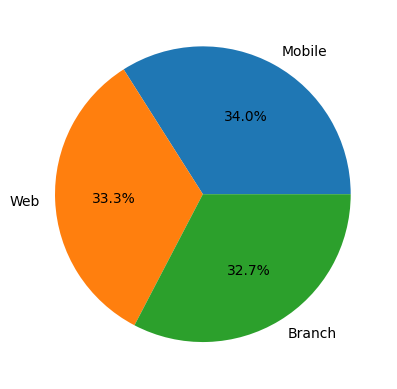

In [ ]:

plt.pie(df['transaction_channel'].value_counts(), labels=df['transaction_channel'].value_counts().index, autopct='%1.1f%%');
df['transaction_channel'].value_counts()

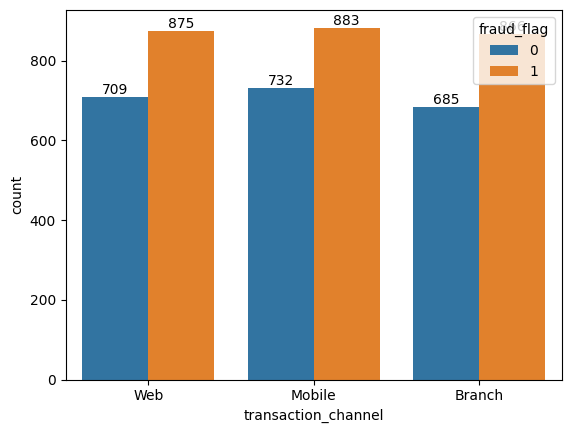

In [ ]:

ax = sns.countplot(data=df,x='transaction_channel',hue='fraud_flag')
for i in ax.containers:
  ax.bar_label(i)

<Axes: xlabel='transaction_hour', ylabel='Count'>

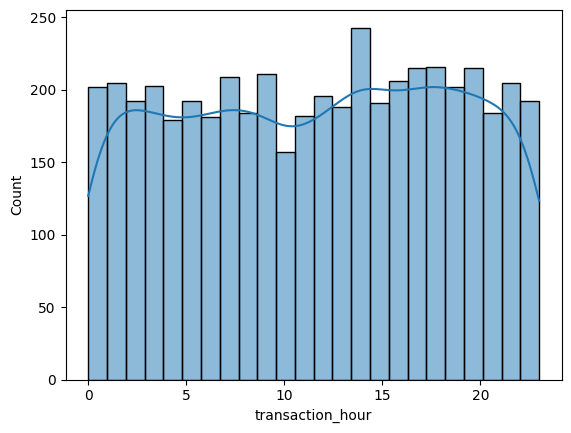

In [ ]:
sns.histplot(data=df, x='transaction_hour',bins=24,kde=True)

<Axes: xlabel='transaction_hour', ylabel='Count'>

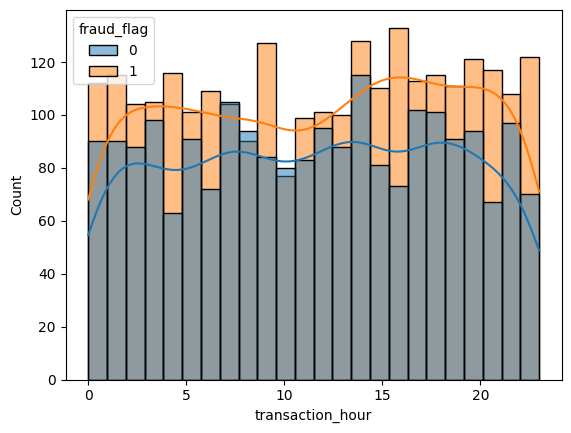

In [ ]:
sns.histplot(data=df, x='transaction_hour', hue='fraud_flag', bins=24 ,kde=True)

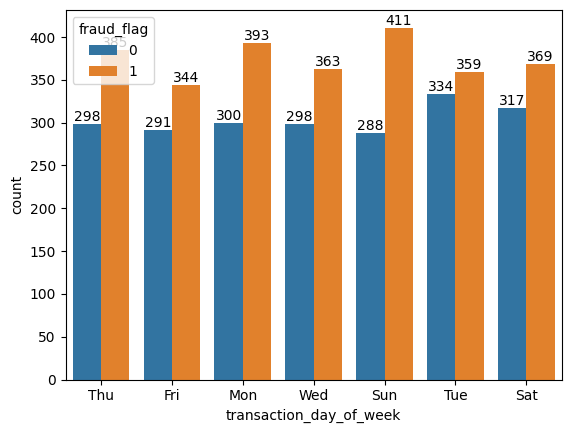

In [ ]:
ax = sns.countplot(data=df, x='transaction_day_of_week',hue='fraud_flag')
for i in ax.containers:
  ax.bar_label(i)

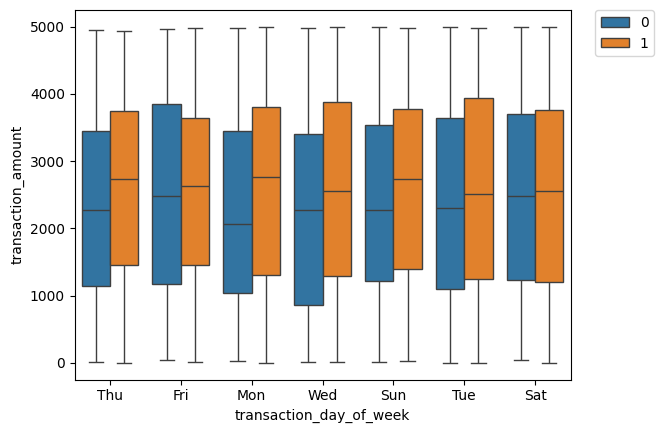

In [ ]:
sns.boxplot(data=df, x='transaction_day_of_week', y='transaction_amount', hue='fraud_flag')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)


,count
transaction_country,
DE,832
TR,818
UK,800
RU,783
US,764
AZ,753


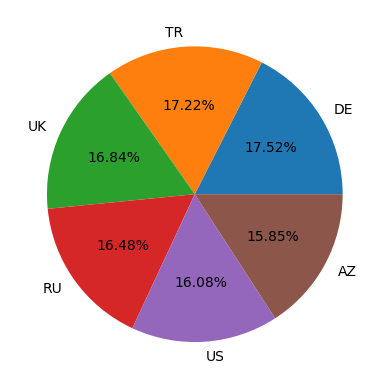

In [ ]:
plt.pie(df['transaction_country'].value_counts(), labels=df['transaction_country'].value_counts().index, autopct='%1.2f%%')
df['transaction_country'].value_counts()

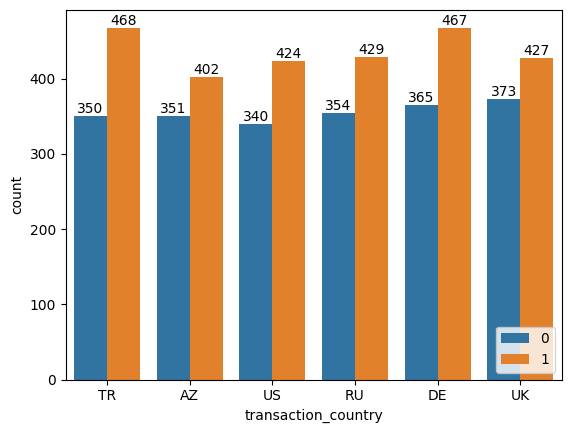

In [ ]:
ax = sns.countplot(data=df, x='transaction_country', hue='fraud_flag')
plt.legend(loc='lower right')
for i in ax.containers:
  ax.bar_label(i)


,count
merchant_category,
Restaurant,994
Luxury,986
Electronics,946
Travel,937
Grocery,887


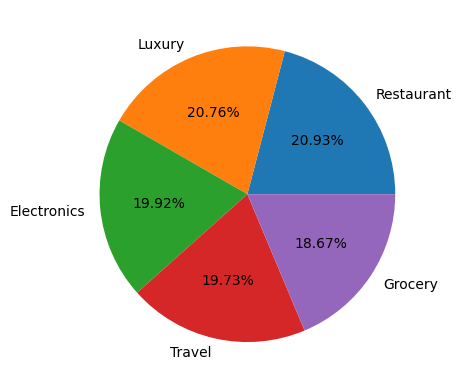

In [ ]:
plt.pie(df['merchant_category'].value_counts(), labels=df['merchant_category'].value_counts().index, autopct='%1.2f%%')
df['merchant_category'].value_counts()

,merchant_risk_score
count,2644.000000
mean,51.020045
std,28.886787
min,0.000000
25%,26.000000
50%,52.000000
75%,76.000000
max,99.000000


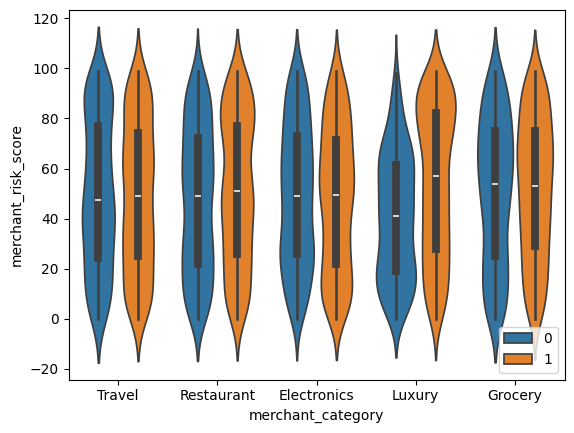

In [ ]:
sns.violinplot(data=df, x='merchant_category', y='merchant_risk_score', hue='fraud_flag')
plt.legend(loc='lower right')

df[df['fraud_flag']==1]['merchant_risk_score'].describe()

,count
card_present_flag,
0.0,3836
1.0,914


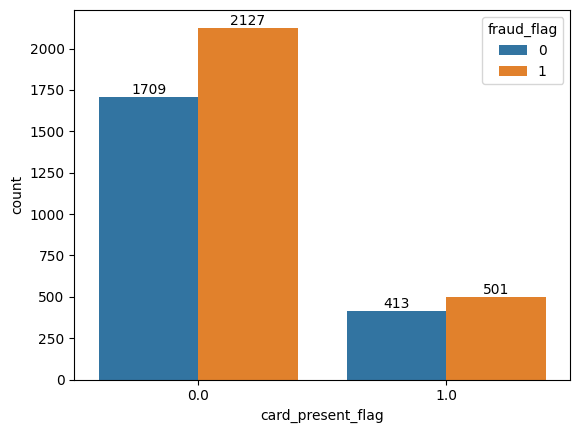

In [ ]:
ax = sns.countplot(data=df, x='card_present_flag', hue='fraud_flag')
for i in ax.containers:
  ax.bar_label(i)

df['card_present_flag'].value_counts()

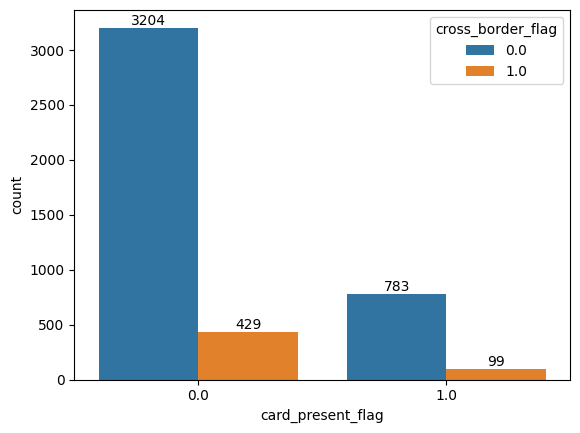

In [ ]:
ax = sns.countplot(data=df, x='card_present_flag', hue='cross_border_flag')
for i in ax.containers:
  ax.bar_label(i)

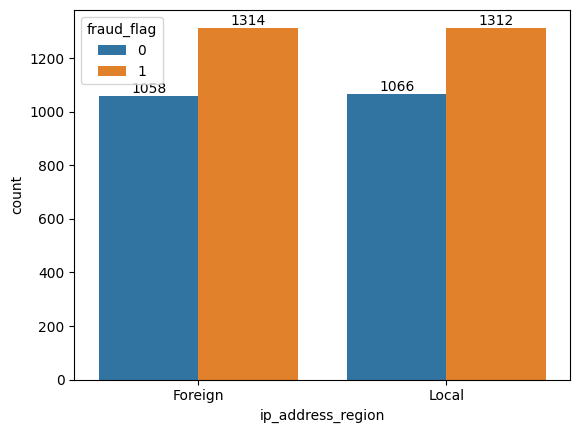

In [ ]:
ax = sns.countplot(data=df, x='ip_address_region', hue='fraud_flag')
for i in ax.containers:
  ax.bar_label(i)

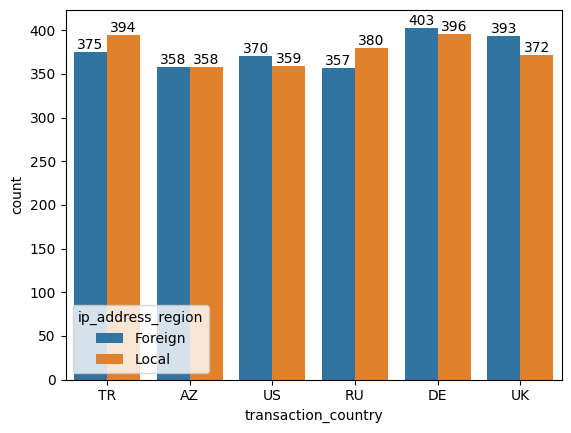

In [ ]:
ax = sns.countplot(data=df, x='transaction_country', hue='ip_address_region')
for i in ax.containers:
  ax.bar_label(i)

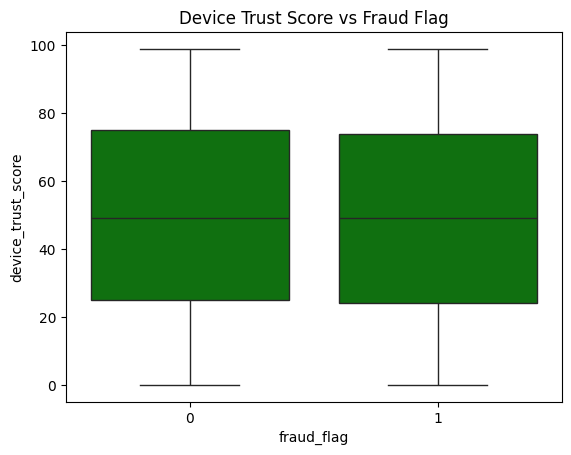

In [ ]:
sns.boxplot(data=df, x='fraud_flag', y='device_trust_score',color='green')
plt.title('Device Trust Score vs Fraud Flag');

<Axes: xlabel='age', ylabel='Count'>

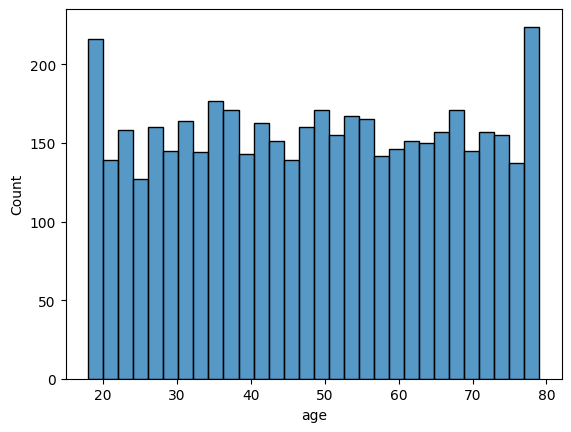

In [ ]:

sns.histplot(data=df, x='age', bins=30)

,count
gender,
Female,2419
Male,2331


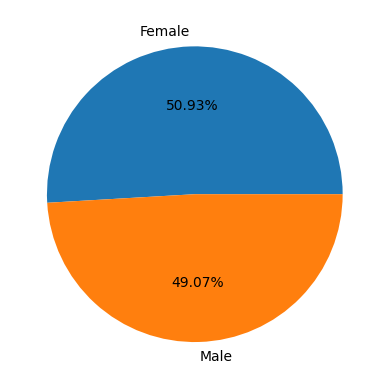

In [ ]:
plt.pie(df['gender'].value_counts(), labels=df['gender'].value_counts().index, autopct='%1.2f%%')
df['gender'].value_counts()


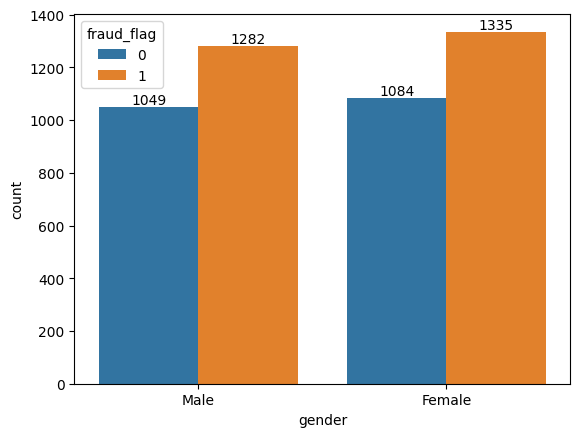

In [ ]:
ax = sns.countplot(data=df, x='gender', hue='fraud_flag')
for i in ax.containers:
  ax.bar_label(i)

Text(0.5, 1.0, 'Account Tenure Days vs Fraud Flag')

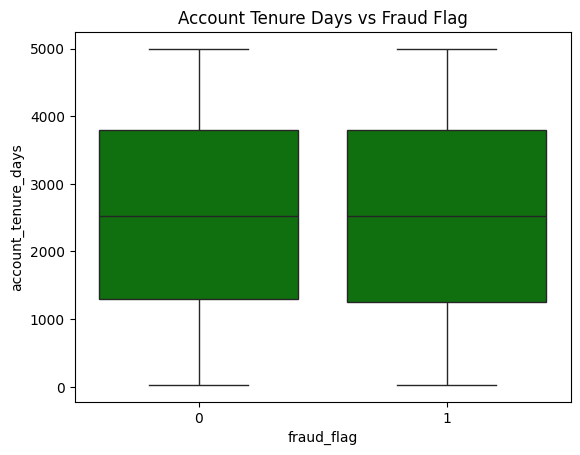

In [ ]:
sns.boxplot(data=df, x='fraud_flag', y='account_tenure_days',color='green')
plt.title('Account Tenure Days vs Fraud Flag')

<Axes: xlabel='fraud_flag', ylabel='avg_monthly_balance'>

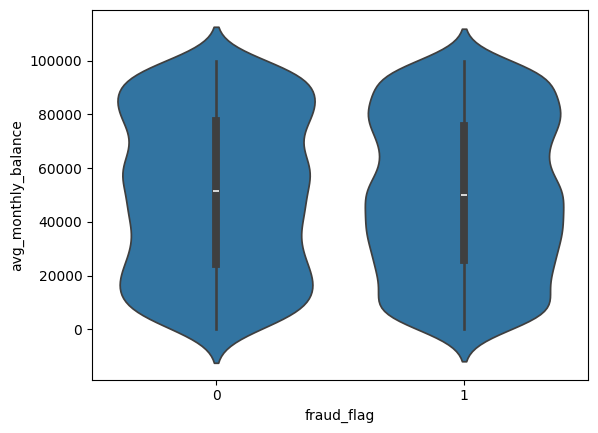

In [ ]:
sns.violinplot(data=df, x='fraud_flag', y='avg_monthly_balance')

Text(0.5, 1.0, 'Credit Score vs Fraud Flag')

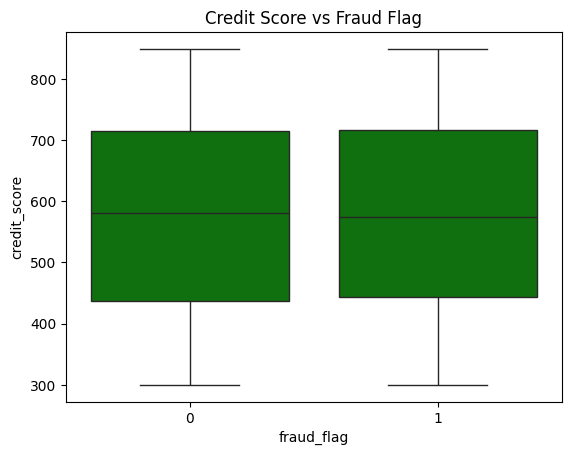

In [ ]:

sns.boxplot(data=df, x='fraud_flag', y='credit_score',color='green')
plt.title('Credit Score vs Fraud Flag')

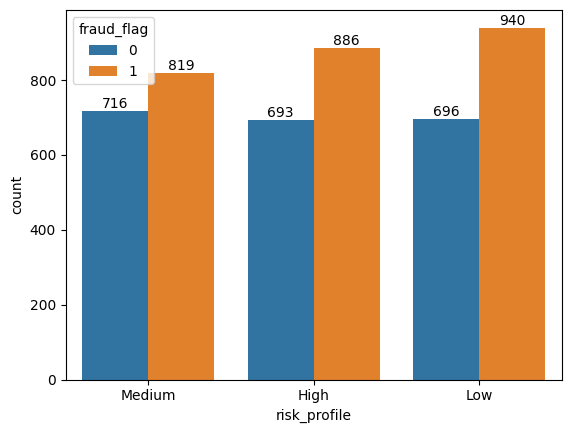

In [ ]:
ax = sns.countplot(data=df, x='risk_profile', hue='fraud_flag')
for i in ax.containers:
  ax.bar_label(i)

In [ ]:
data = {'transactions_last_24h' : 1,
        'transactions_last_7d' : 7,
        'transactions_last_30d' : 30}
data.values()

dict_values([1, 7, 30])

Text(0.5, 1.0, 'Transactions Last 24 Hours vs Fraud Flag')

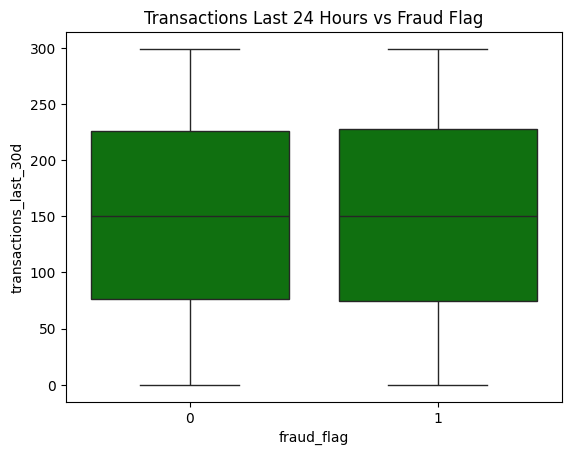

In [ ]:
sns.boxplot(data=df, x='fraud_flag', y='transactions_last_30d',color='green')
plt.title('Transactions Last 24 Hours vs Fraud Flag')

<Axes: xlabel='fraud_flag', ylabel='device_change_30d'>

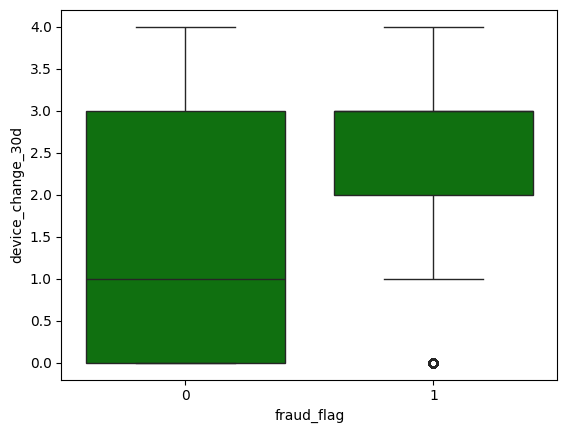

In [ ]:
sns.boxplot(data=df, x='fraud_flag', y='device_change_30d',color='green')

<Axes: xlabel='fraud_flag', ylabel='failed_login_attempts_24h'>

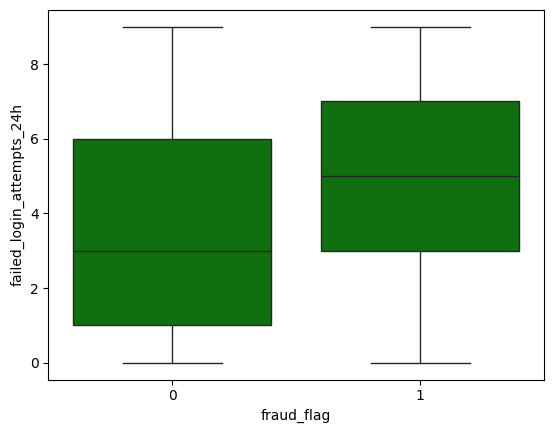

In [ ]:
sns.boxplot(data=df, x='fraud_flag', y='failed_login_attempts_24h',color='green')

In [ ]:
df.head(4)

,transaction_amount,transaction_type,transaction_channel,transaction_hour,transaction_day_of_week,transaction_country,transaction_currency,merchant_category,merchant_risk_score,card_type,card_present_flag,cross_border_flag,ip_address_region,device_trust_score,age,gender,region,account_tenure_days,account_type,avg_monthly_balance,total_loans,credit_score,loyalty_score,risk_profile,transactions_last_24h,transactions_last_7d,transactions_last_30d,avg_transaction_amount_7d,avg_transaction_amount_30d,failed_login_attempts_24h,device_change_30d,ip_change_30d,mobile_app_logins_30d,web_logins_30d,branch_visits_30d,blacklist_flag,aml_alert_flag,suspicious_device_flag,suspicious_ip_flag,chargeback_count_12m,previous_fraud_flag,support_tickets_6m,internal_risk_score,external_risk_score,compliance_score,velocity_score,amount_to_balance_ratio,suspicious_behavior_score,fraud_flag,fraud_probability
0,1873.326054,ATM,Web,17.0,Thu,TR,NaN,Travel,NaN,Credit,1.0,0.0,Foreign,24.0,50.0,Male,Rural,4657.0,Business,96285.364820,7.0,609.0,93.0,Medium,26.0,85.0,248.0,250.246868,1848.669085,1.0,2.0,2.0,96.0,179.0,6.0,0.0,0.0,0.0,0.0,6.0,0.0,0.0,67.0,4.0,36.0,0.915368,1.435066,0.964333,0,0.370924
1,4753.620818,Wire,Mobile,15.0,Fri,NaN,AZN,Restaurant,86.0,Credit,0.0,0.0,Local,47.0,68.0,Female,Urban,NaN,Business,81536.471290,5.0,696.0,96.0,Medium,14.0,14.0,0.0,NaN,256.357273,8.0,2.0,0.0,102.0,73.0,NaN,0.0,0.0,0.0,1.0,6.0,0.0,19.0,71.0,99.0,41.0,0.813364,1.311163,0.553211,1,0.496739
2,3660.237715,ATM,Mobile,16.0,Thu,TR,GBP,Travel,28.0,Debit,0.0,0.0,Local,72.0,46.0,Male,Urban,1775.0,Savings,69498.434019,3.0,805.0,9.0,NaN,7.0,22.0,296.0,108.521907,1233.907622,6.0,0.0,4.0,2.0,42.0,7.0,0.0,0.0,1.0,1.0,0.0,0.0,15.0,34.0,79.0,0.0,0.939946,0.672257,0.287086,1,0.456115
3,2993.693763,Wire,Mobile,6.0,Mon,AZ,USD,NaN,40.0,Debit,NaN,1.0,Foreign,60.0,48.0,Male,Urban,4104.0,Savings,55005.947033,4.0,794.0,NaN,High,15.0,12.0,23.0,818.759024,2122.654157,4.0,4.0,0.0,115.0,NaN,18.0,0.0,1.0,0.0,0.0,6.0,0.0,12.0,93.0,80.0,8.0,0.340578,1.596243,0.386247,1,0.433529


## Missing Value Handling

In [ ]:
df.isnull().sum().to_frame().T

,transaction_amount,transaction_type,transaction_channel,transaction_hour,transaction_day_of_week,transaction_country,transaction_currency,merchant_category,merchant_risk_score,card_type,card_present_flag,cross_border_flag,ip_address_region,device_trust_score,age,gender,region,account_tenure_days,account_type,avg_monthly_balance,total_loans,credit_score,loyalty_score,risk_profile,transactions_last_24h,transactions_last_7d,transactions_last_30d,avg_transaction_amount_7d,avg_transaction_amount_30d,failed_login_attempts_24h,device_change_30d,ip_change_30d,mobile_app_logins_30d,web_logins_30d,branch_visits_30d,blacklist_flag,aml_alert_flag,suspicious_device_flag,suspicious_ip_flag,chargeback_count_12m,previous_fraud_flag,support_tickets_6m,internal_risk_score,external_risk_score,compliance_score,velocity_score,amount_to_balance_ratio,suspicious_behavior_score,fraud_flag,fraud_probability
0,250,250,250,250,250,250,250,250,250,250,250,250,250,250,250,250,250,250,250,250,250,250,250,250,250,250,250,250,250,250,250,250,250,250,250,250,250,250,250,250,250,250,250,250,250,250,250,250,0,0


In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

In [ ]:
from sklearn.impute import KNNImputer
knn = KNNImputer(n_neighbors=5)

df[['transaction_amount']] = knn.fit_transform(df[['transaction_amount']])

In [ ]:
cat_cols = df.select_dtypes(include='object').columns



In [ ]:
valid_cols = [c for c in cat_cols if df[c].isnull().mean() < 0.3]


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

def rf_impute_advanced(df, col):
    known = df[df[col].notnull()]
    unknown = df[df[col].isnull()]

    X = df.drop(col, axis=1)

    num_cols = X.select_dtypes(include='number').columns
    cat_cols = X.select_dtypes(include='object').columns

    pre = ColumnTransformer([
        ('num', 'passthrough', num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ])

    model = Pipeline([
        ('prep', pre),
        ('rf', RandomForestClassifier(n_estimators=300, max_depth=12))
    ])

    model.fit(known.drop(col, axis=1), known[col])

    preds = model.predict(unknown.drop(col, axis=1))
    df.loc[df[col].isnull(), col] = preds

    return df


In [ ]:
for col in cat_cols:
    df = rf_impute_advanced(df, col)


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

def rf_impute_regression(df, col):
    known = df[df[col].notnull()]
    unknown = df[df[col].isnull()]

    X = df.drop(col, axis=1)

    num_cols = X.select_dtypes(include='number').columns
    cat_cols = X.select_dtypes(include='object').columns

    pre = ColumnTransformer([
        ('num', 'passthrough', num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ])

    model = Pipeline([
        ('prep', pre),
        ('rf', RandomForestRegressor(
            n_estimators=120,
            max_depth=10,
            random_state=42,
            n_jobs=-1
        ))
    ])

    model.fit(known.drop(col, axis=1), known[col])
    preds = model.predict(unknown.drop(col, axis=1))

    df.loc[df[col].isnull(), col] = preds
    return df


In [ ]:
num_cols = df.select_dtypes(include='number').columns

for col in num_cols:
    if df[col].isnull().sum() > 0:
        df = rf_impute_regression(df, col)


In [ ]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
df.head()

,transaction_amount,transaction_type,transaction_channel,transaction_hour,transaction_day_of_week,transaction_country,transaction_currency,merchant_category,merchant_risk_score,card_type,card_present_flag,cross_border_flag,ip_address_region,device_trust_score,age,gender,region,account_tenure_days,account_type,avg_monthly_balance,total_loans,credit_score,loyalty_score,risk_profile,transactions_last_24h,transactions_last_7d,transactions_last_30d,avg_transaction_amount_7d,avg_transaction_amount_30d,failed_login_attempts_24h,device_change_30d,ip_change_30d,mobile_app_logins_30d,web_logins_30d,branch_visits_30d,blacklist_flag,aml_alert_flag,suspicious_device_flag,suspicious_ip_flag,chargeback_count_12m,previous_fraud_flag,support_tickets_6m,internal_risk_score,external_risk_score,compliance_score,velocity_score,amount_to_balance_ratio,suspicious_behavior_score,fraud_flag,fraud_probability
0,1873.326054,ATM,Web,17.0,Thu,TR,AZN,Travel,48.746344,Credit,1.000000,0.0,Foreign,24.0,50.0,Male,Rural,4657.000000,Business,96285.364820,7.0,609.0,93.000000,Medium,26.0,85.0,248.000000,250.246868,1848.669085,1.0,2.0,2.0,96.0,179.000000,6.000000,0.0,0.0,0.0,0.0,6.0,0.0,0.0,67.0,4.0,36.0,0.915368,1.435066,0.964333,0,0.370924
1,4753.620818,Wire,Mobile,15.0,Fri,RU,AZN,Restaurant,86.000000,Credit,0.000000,0.0,Local,47.0,68.0,Female,Urban,2712.746518,Business,81536.471290,5.0,696.0,96.000000,Medium,14.0,14.0,0.000000,949.209828,256.357273,8.0,2.0,0.0,102.0,73.000000,9.716379,0.0,0.0,0.0,1.0,6.0,0.0,19.0,71.0,99.0,41.0,0.813364,1.311163,0.553211,1,0.496739
2,3660.237715,ATM,Mobile,16.0,Thu,TR,GBP,Travel,28.000000,Debit,0.000000,0.0,Local,72.0,46.0,Male,Urban,1775.000000,Savings,69498.434019,3.0,805.0,9.000000,Medium,7.0,22.0,296.000000,108.521907,1233.907622,6.0,0.0,4.0,2.0,42.000000,7.000000,0.0,0.0,1.0,1.0,0.0,0.0,15.0,34.0,79.0,0.0,0.939946,0.672257,0.287086,1,0.456115
3,2993.693763,Wire,Mobile,6.0,Mon,AZ,USD,Restaurant,40.000000,Debit,0.181745,1.0,Foreign,60.0,48.0,Male,Urban,4104.000000,Savings,55005.947033,4.0,794.0,49.064328,High,15.0,12.0,23.000000,818.759024,2122.654157,4.0,4.0,0.0,115.0,93.368908,18.000000,0.0,1.0,0.0,0.0,6.0,0.0,12.0,93.0,80.0,8.0,0.340578,1.596243,0.386247,1,0.433529
4,780.937184,Wire,Mobile,11.0,Wed,US,EUR,Electronics,51.292893,Credit,0.000000,0.0,Local,34.0,61.0,Female,Rural,2535.000000,Savings,92081.748823,1.0,343.0,57.000000,Low,7.0,21.0,152.805667,1485.509646,2907.076786,4.0,1.0,1.0,17.0,100.000000,0.000000,0.0,0.0,0.0,0.0,1.0,0.0,3.0,31.0,11.0,27.0,0.990250,1.235550,0.810898,0,0.340988


## Statistic

In [ ]:
df.corr(numeric_only=True)['fraud_flag'].sort_values(ascending=False).to_frame().T

,fraud_flag,device_change_30d,failed_login_attempts_24h,suspicious_device_flag,suspicious_ip_flag,fraud_probability,blacklist_flag,previous_fraud_flag,cross_border_flag,transaction_amount,merchant_risk_score,compliance_score,suspicious_behavior_score,avg_transaction_amount_7d,transaction_hour,ip_change_30d,loyalty_score,mobile_app_logins_30d,velocity_score,age,avg_transaction_amount_30d,credit_score,transactions_last_24h,total_loans,transactions_last_30d,internal_risk_score,aml_alert_flag,card_present_flag,account_tenure_days,external_risk_score,device_trust_score,avg_monthly_balance,transactions_last_7d,support_tickets_6m,branch_visits_30d,amount_to_balance_ratio,web_logins_30d,chargeback_count_12m
fraud_flag,1.0,0.299438,0.274803,0.267816,0.237139,0.205382,0.201153,0.1192,0.11399,0.05896,0.05528,0.033465,0.028884,0.024912,0.017556,0.016187,0.013398,0.012036,0.009402,0.006061,0.004702,0.00266,0.002299,-0.000812,-0.000972,-0.002694,-0.003828,-0.005119,-0.007093,-0.007714,-0.008062,-0.008514,-0.008627,-0.008985,-0.014208,-0.014773,-0.025627,-0.030224


In [ ]:
def iqr_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = series[(series < lower) | (series > upper)]

    return {
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "lower_bound": lower,
        "upper_bound": upper,
        "outliers_count": outliers.shape[0],
        "outliers": outliers
    }


### transaction_amount statistic

In [ ]:
from scipy.stats import shapiro

stat, p = shapiro(df['transaction_amount'])
print(p)

1.3893684925834802e-34


In [ ]:
result = iqr_outliers(df['avg_monthly_balance'])
print(result['outliers_count'])

'''
The transaction_amount feature does not follow a normal distribution (Shapiro-Wilk p < 0.05),
indicating right-skewness and heavy-tailed behavior. However, no extreme outliers were detected
using the IQR method, suggesting a stable but non-Gaussian distribution typical for financial
transaction data.
'''


0


'\nThe transaction_amount feature does not follow a normal distribution (Shapiro-Wilk p < 0.05),\nindicating right-skewness and heavy-tailed behavior. However, no extreme outliers were detected\nusing the IQR method, suggesting a stable but non-Gaussian distribution typical for financial\ntransaction data.\n'

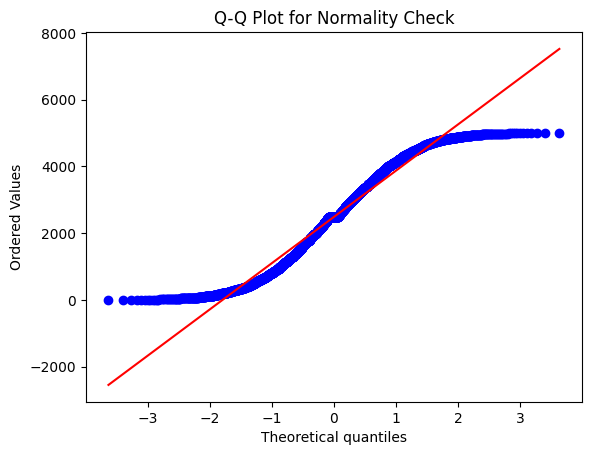

In [ ]:
import scipy.stats as stats
import matplotlib.pyplot as plt

stats.probplot(df['transaction_amount'], dist="norm", plot=plt)
plt.title("Q-Q Plot for Normality Check")
plt.show()


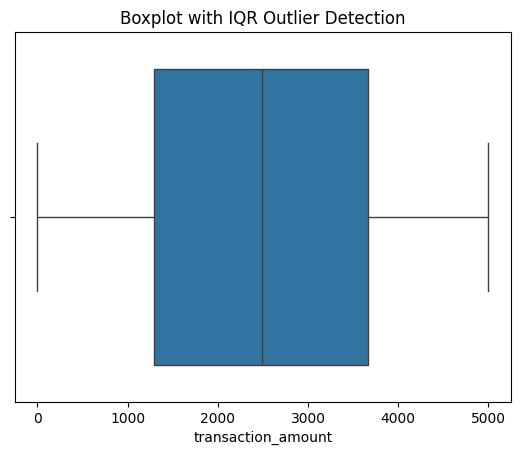

In [ ]:
sns.boxplot(x=df['transaction_amount'])
plt.title("Boxplot with IQR Outlier Detection")
plt.show()


### device_change_30d normality

In [ ]:
from scipy.stats import shapiro

stat, p = shapiro(df['device_change_30d'])
print(p)

6.432279055234719e-50


In [ ]:
g0 = df[df['fraud_flag'] == 0]['device_change_30d']
g1 = df[df['fraud_flag'] == 1]['device_change_30d']

In [ ]:
from scipy.stats import mannwhitneyu

stat, p = mannwhitneyu(g0,g1)
print(p)

1.3094519416371163e-98


In [ ]:
'''
device_change_30d dəyişəni normal paylanmadığı üçün Mann–Whitney U testi tətbiq edilmişdir.
Test nəticəsi göstərir ki, fraud və non-fraud əməliyyatları arasında bu dəyişən üzrə
son dərəcə əhəmiyyətli fərq mövcuddur (p < 1e-97). Bu, device_change_30d göstəricisinin
fraud riskinin proqnozlaşdırılmasında yüksək diskriminativ gücə malik olduğunu sübut edir.
'''

'\ndevice_change_30d dəyişəni normal paylanmadığı üçün Mann–Whitney U testi tətbiq edilmişdir.\nTest nəticəsi göstərir ki, fraud və non-fraud əməliyyatları arasında bu dəyişən üzrə\nson dərəcə əhəmiyyətli fərq mövcuddur (p < 1e-97). Bu, device_change_30d göstəricisinin\nfraud riskinin proqnozlaşdırılmasında yüksək diskriminativ gücə malik olduğunu sübut edir.\n'

In [ ]:
from scipy.stats import shapiro, ttest_ind, mannwhitneyu

def statistical_test_all_numeric(df, target='fraud_flag'):
    results = []

    num_cols = df.select_dtypes(include='number').columns.drop(target)

    for col in num_cols:
        g0 = df[df[target] == 0][col].dropna()
        g1 = df[df[target] == 1][col].dropna()

        # Normality
        p_normal = shapiro(df[col].sample(min(5000, len(df[col])))).pvalue

        if p_normal > 0.05:
            stat, p_test = ttest_ind(g0, g1, equal_var=False)
            test_name = 'T-test'
        else:
            stat, p_test = mannwhitneyu(g0, g1)
            test_name = 'Mann-Whitney'

        results.append({
            'feature': col,
            'normality_p': p_normal,
            'test_used': test_name,
            'p_value': p_test
        })

    return pd.DataFrame(results).sort_values('p_value')


In [ ]:
stat_results = statistical_test_all_numeric(df, target='fraud_flag')
stat_results


,feature,normality_p,test_used,p_value
18,device_change_30d,6.432279e-50,Mann-Whitney,1.309452e-98
17,failed_login_attempts_24h,1.747733e-40,Mann-Whitney,3.941380e-84
25,suspicious_device_flag,1.814616e-85,Mann-Whitney,3.005615e-57
36,fraud_probability,6.022360e-07,Mann-Whitney,6.032229e-46
26,suspicious_ip_flag,1.116772e-86,Mann-Whitney,9.593866e-42
28,previous_fraud_flag,1.343580e-92,Mann-Whitney,5.623357e-38
23,blacklist_flag,5.934701e-89,Mann-Whitney,1.123226e-26
4,cross_border_flag,1.762708e-84,Mann-Whitney,1.012685e-11
0,transaction_amount,1.389368e-34,Mann-Whitney,2.158839e-05
2,merchant_risk_score,8.042773e-34,Mann-Whitney,8.593712e-05


### Categorical statistic test

In [ ]:
df.select_dtypes('object').columns

Index(['transaction_type', 'transaction_channel', 'transaction_day_of_week',
       'transaction_country', 'transaction_currency', 'merchant_category',
       'card_type', 'ip_address_region', 'gender', 'region', 'account_type',
       'risk_profile'],
      dtype='object')

In [ ]:
from scipy.stats import chi2_contingency, pointbiserialr

def categorical_target_analysis(df, categorical_cols, target='fraud_flag'):
    """
    Categorical column-ların target ilə əlaqəsini yoxlayır.
    Binary column → Point-Biserial Correlation
    Multi-class → Chi-Square + Cramér's V
    Çıxış → dataframe ilə test adı, p-value və effect size
    """
    results = []

    for col in categorical_cols:
        unique_vals = df[col].nunique()

        # Binary
        if unique_vals == 2:

            mapping = {val:i for i,val in enumerate(df[col].unique())}
            numeric_col = df[col].map(mapping)

            corr, p = pointbiserialr(numeric_col, df[target])
            results.append({
                'feature': col,
                'type': 'binary',
                'test_used': 'Point-Biserial',
                'p_value': p,
                'effect_size': corr
            })

        # Multi-class
        else:
            table = pd.crosstab(df[col], df[target])
            chi2, p, dof, expected = chi2_contingency(table)
            n = table.sum().sum()
            cramers_v = np.sqrt(chi2 / (n * (min(table.shape)-1)))

            results.append({
                'feature': col,
                'type': 'multi-class',
                'test_used': 'Chi-Square + Cramer\'s V',
                'p_value': p,
                'effect_size': cramers_v
            })

    return pd.DataFrame(results).sort_values('p_value')



categorical_cols = [
    'transaction_type', 'transaction_channel', 'transaction_day_of_week',
    'transaction_country', 'transaction_currency', 'merchant_category',
    'card_type', 'ip_address_region', 'gender', 'region', 'account_type',
    'risk_profile'
]

cat_analysis = categorical_target_analysis(df, categorical_cols)
print(cat_analysis)


                    feature         type                test_used  \
5         merchant_category  multi-class  Chi-Square + Cramer's V   
0          transaction_type  multi-class  Chi-Square + Cramer's V   
11             risk_profile  multi-class  Chi-Square + Cramer's V   
2   transaction_day_of_week  multi-class  Chi-Square + Cramer's V   
9                    region  multi-class  Chi-Square + Cramer's V   
4      transaction_currency  multi-class  Chi-Square + Cramer's V   
3       transaction_country  multi-class  Chi-Square + Cramer's V   
10             account_type  multi-class  Chi-Square + Cramer's V   
6                 card_type  multi-class  Chi-Square + Cramer's V   
1       transaction_channel  multi-class  Chi-Square + Cramer's V   
8                    gender       binary           Point-Biserial   
7         ip_address_region       binary           Point-Biserial   

         p_value  effect_size  
5   1.079673e-09     0.097693  
0   3.167549e-02     0.042018  
11  1.

In [ ]:
df.head()

,transaction_amount,transaction_type,transaction_channel,transaction_hour,transaction_day_of_week,transaction_country,transaction_currency,merchant_category,merchant_risk_score,card_type,card_present_flag,cross_border_flag,ip_address_region,device_trust_score,age,gender,region,account_tenure_days,account_type,avg_monthly_balance,total_loans,credit_score,loyalty_score,risk_profile,transactions_last_24h,transactions_last_7d,transactions_last_30d,avg_transaction_amount_7d,avg_transaction_amount_30d,failed_login_attempts_24h,device_change_30d,ip_change_30d,mobile_app_logins_30d,web_logins_30d,branch_visits_30d,blacklist_flag,aml_alert_flag,suspicious_device_flag,suspicious_ip_flag,chargeback_count_12m,previous_fraud_flag,support_tickets_6m,internal_risk_score,external_risk_score,compliance_score,velocity_score,amount_to_balance_ratio,suspicious_behavior_score,fraud_flag,fraud_probability
0,1873.326054,ATM,Web,17.0,Thu,TR,AZN,Travel,48.746344,Credit,1.000000,0.0,Foreign,24.0,50.0,Male,Rural,4657.000000,Business,96285.364820,7.0,609.0,93.000000,Medium,26.0,85.0,248.000000,250.246868,1848.669085,1.0,2.0,2.0,96.0,179.000000,6.000000,0.0,0.0,0.0,0.0,6.0,0.0,0.0,67.0,4.0,36.0,0.915368,1.435066,0.964333,0,0.370924
1,4753.620818,Wire,Mobile,15.0,Fri,RU,AZN,Restaurant,86.000000,Credit,0.000000,0.0,Local,47.0,68.0,Female,Urban,2712.746518,Business,81536.471290,5.0,696.0,96.000000,Medium,14.0,14.0,0.000000,949.209828,256.357273,8.0,2.0,0.0,102.0,73.000000,9.716379,0.0,0.0,0.0,1.0,6.0,0.0,19.0,71.0,99.0,41.0,0.813364,1.311163,0.553211,1,0.496739
2,3660.237715,ATM,Mobile,16.0,Thu,TR,GBP,Travel,28.000000,Debit,0.000000,0.0,Local,72.0,46.0,Male,Urban,1775.000000,Savings,69498.434019,3.0,805.0,9.000000,Medium,7.0,22.0,296.000000,108.521907,1233.907622,6.0,0.0,4.0,2.0,42.000000,7.000000,0.0,0.0,1.0,1.0,0.0,0.0,15.0,34.0,79.0,0.0,0.939946,0.672257,0.287086,1,0.456115
3,2993.693763,Wire,Mobile,6.0,Mon,AZ,USD,Restaurant,40.000000,Debit,0.181745,1.0,Foreign,60.0,48.0,Male,Urban,4104.000000,Savings,55005.947033,4.0,794.0,49.064328,High,15.0,12.0,23.000000,818.759024,2122.654157,4.0,4.0,0.0,115.0,93.368908,18.000000,0.0,1.0,0.0,0.0,6.0,0.0,12.0,93.0,80.0,8.0,0.340578,1.596243,0.386247,1,0.433529
4,780.937184,Wire,Mobile,11.0,Wed,US,EUR,Electronics,51.292893,Credit,0.000000,0.0,Local,34.0,61.0,Female,Rural,2535.000000,Savings,92081.748823,1.0,343.0,57.000000,Low,7.0,21.0,152.805667,1485.509646,2907.076786,4.0,1.0,1.0,17.0,100.000000,0.000000,0.0,0.0,0.0,0.0,1.0,0.0,3.0,31.0,11.0,27.0,0.990250,1.235550,0.810898,0,0.340988


## Data Preprocessing

In [ ]:
df.select_dtypes('object').head()

,transaction_type,transaction_channel,transaction_day_of_week,transaction_country,transaction_currency,merchant_category,card_type,ip_address_region,gender,region,account_type,risk_profile
0,ATM,Web,Thu,TR,AZN,Travel,Credit,Foreign,Male,Rural,Business,Medium
1,Wire,Mobile,Fri,RU,AZN,Restaurant,Credit,Local,Female,Urban,Business,Medium
2,ATM,Mobile,Thu,TR,GBP,Travel,Debit,Local,Male,Urban,Savings,Medium
3,Wire,Mobile,Mon,AZ,USD,Restaurant,Debit,Foreign,Male,Urban,Savings,High
4,Wire,Mobile,Wed,US,EUR,Electronics,Credit,Local,Female,Rural,Savings,Low


### OneHotEncoding

In [ ]:
transaction_amount = pd.get_dummies(df['transaction_type'], dtype=int, drop_first=True)
transaction_channel = pd.get_dummies(df['transaction_channel'], dtype=int, drop_first=True)
transaction_country = pd.get_dummies(df['transaction_country'], dtype=int, drop_first=True)
transaction_currency = pd.get_dummies(df['transaction_currency'], dtype=int, drop_first=True)
merchant_category = pd.get_dummies(df['merchant_category'], dtype=int, drop_first=True)
card_type = pd.get_dummies(df['card_type'], dtype=int, drop_first=True)
region = pd.get_dummies(df['region'], dtype=int, drop_first=True)
account_type = pd.get_dummies(df['account_type'], dtype=int, drop_first=True)

In [ ]:
df = pd.concat([df, transaction_amount, transaction_channel, transaction_country, transaction_currency, merchant_category, card_type, region, account_type], axis=1)

In [ ]:
df = df.drop(['transaction_type', 'transaction_channel', 'transaction_country', 'transaction_currency', 'merchant_category', 'card_type', 'region', 'account_type'], axis=1)

### OrdinalEncoding

In [ ]:
for i in df['transaction_day_of_week'].unique():
  print(i)
  print(df[df['transaction_day_of_week']==i]['fraud_flag'].value_counts())

Thu
fraud_flag
1    412
0    310
Name: count, dtype: int64
Fri
fraud_flag
1    351
0    300
Name: count, dtype: int64
Mon
fraud_flag
1    410
0    316
Name: count, dtype: int64
Wed
fraud_flag
1    374
0    313
Name: count, dtype: int64
Sun
fraud_flag
1    439
0    303
Name: count, dtype: int64
Tue
fraud_flag
1    396
0    361
Name: count, dtype: int64
Sat
fraud_flag
1    387
0    328
Name: count, dtype: int64


In [ ]:
day_ordinal_map = {
    'Fri': 1,
    'Tue': 2,
    'Wed': 3,
    'Sat': 4,
    'Thu': 5,
    'Mon': 6,
    'Sun': 7
}

df['transaction_day_of_week'] = df['transaction_day_of_week'].map(day_ordinal_map)


In [ ]:
risk_profile_ordinal_map = {
    'Low' : 1,
    'Medium' : 2,
    'High' : 3
}

df['risk_profile'] = df['risk_profile'].map(risk_profile_ordinal_map)

### LabelEncoding

In [ ]:
le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])

In [ ]:
df['ip_address_region'] = le.fit_transform(df['ip_address_region'])

## Preprocessing for ML

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('fraud_flag', axis=1)
y = df['fraud_flag']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

In [ ]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((4000, 64), (1000, 64), (4000,), (1000,))

## Machine Learning Classification Model

### Logictic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report



In [ ]:
standard = StandardScaler()
X_train_scaled = standard.fit_transform(X_train)
X_test_scaled = standard.transform(X_test)

lr = LogisticRegression(
    max_iter = 2000,
    solver='saga',
    class_weight='balanced',
    penalty = 'l1')

lr.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(class_weight='balanced', max_iter=2000, penalty='l1',
                   solver='saga')

In [ ]:
y_pred = lr.predict(X_test)

In [ ]:
print(accuracy_score(y_test, y_pred))

0.516


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.46      0.52      0.49       443
           1       0.57      0.51      0.54       557

    accuracy                           0.52      1000
   macro avg       0.52      0.52      0.51      1000
weighted avg       0.52      0.52      0.52      1000



In [ ]:
print(confusion_matrix(y_test, y_pred))

[[230 213]
 [271 286]]


#### LogisticRegression Scaler data

In [ ]:
lr.fit(X_train_scaled, y_train)


LogisticRegression(class_weight='balanced', max_iter=2000, penalty='l1',
                   solver='saga')

In [ ]:
y_pred_scaled = lr.predict(X_test_scaled)

In [ ]:
print(accuracy_score(y_test, y_pred_scaled))

0.827


In [ ]:
print(classification_report(y_test, y_pred_scaled))

              precision    recall  f1-score   support

           0       0.79      0.83      0.81       443
           1       0.86      0.82      0.84       557

    accuracy                           0.83      1000
   macro avg       0.82      0.83      0.83      1000
weighted avg       0.83      0.83      0.83      1000



In [ ]:
print(confusion_matrix(y_test, y_pred_scaled))

[[369  74]
 [ 99 458]]


### SVM Model

In [ ]:
from sklearn.svm import SVC

svc = SVC()
svc.fit(X_train, y_train)

SVC()

In [ ]:
y_pred = svc.predict(X_test)

In [ ]:
print(accuracy_score(y_test, y_pred))

0.557


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       443
           1       0.56      1.00      0.72       557

    accuracy                           0.56      1000
   macro avg       0.28      0.50      0.36      1000
weighted avg       0.31      0.56      0.40      1000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
print(confusion_matrix(y_test, y_pred))

[[  0 443]
 [  0 557]]


#### SVM Model Scaler Data

In [ ]:
standard = StandardScaler()
X_train_scaled = standard.fit_transform(X_train)
X_test_scaled = standard.transform(X_test)

svc.fit(X_train_scaled, y_train)

SVC()

In [ ]:
y_pred_scaled = svc.predict(X_test_scaled)

In [ ]:
print(accuracy_score(y_test, y_pred_scaled))

0.843


In [ ]:
print(classification_report(y_test, y_pred_scaled))

              precision    recall  f1-score   support

           0       0.82      0.82      0.82       443
           1       0.86      0.86      0.86       557

    accuracy                           0.84      1000
   macro avg       0.84      0.84      0.84      1000
weighted avg       0.84      0.84      0.84      1000



In [ ]:
print(confusion_matrix(y_test, y_pred_scaled))

[[365  78]
 [ 79 478]]


### DecisionTreeClassifier Model

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dtc = DecisionTreeClassifier(
    max_depth=10,
    random_state=42,
    min_samples_split = 20,
    min_samples_leaf = 10,
    criterion = 'log_loss',
    min_weight_fraction_leaf = 0.01
)

dtc.fit(X_train, y_train)

DecisionTreeClassifier(criterion='log_loss', max_depth=10, min_samples_leaf=10,
                       min_samples_split=20, min_weight_fraction_leaf=0.01,
                       random_state=42)

In [ ]:
y_pred = dtc.predict(X_test)

In [ ]:
print(accuracy_score(y_test, y_pred))

0.917


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.90      0.91       443
           1       0.92      0.93      0.93       557

    accuracy                           0.92      1000
   macro avg       0.92      0.92      0.92      1000
weighted avg       0.92      0.92      0.92      1000



In [ ]:
print(confusion_matrix(y_test, y_pred))

[[399  44]
 [ 39 518]]


#### DecisionTreeClassifier Model Scaler Data

In [ ]:
standard = StandardScaler()
X_train_scaled = standard.fit_transform(X_train)
X_test_scaled = standard.transform(X_test)

dtc = DecisionTreeClassifier(
    max_depth=10,
    random_state=42,
    min_samples_split = 20,
    min_samples_leaf = 10,
    criterion = 'log_loss',
    min_weight_fraction_leaf = 0.005,
    class_weight = 'balanced',
)

dtc.fit(X_train_scaled, y_train)

DecisionTreeClassifier(class_weight='balanced', criterion='log_loss',
                       max_depth=10, min_samples_leaf=10, min_samples_split=20,
                       min_weight_fraction_leaf=0.005, random_state=42)

In [ ]:
y_pred_scaler = dtc.predict(X_test_scaled)

In [ ]:
print(accuracy_score(y_test, y_pred_scaler))

0.92


In [ ]:
print(classification_report(y_test, y_pred_scaler))

              precision    recall  f1-score   support

           0       0.92      0.90      0.91       443
           1       0.92      0.94      0.93       557

    accuracy                           0.92      1000
   macro avg       0.92      0.92      0.92      1000
weighted avg       0.92      0.92      0.92      1000



In [ ]:
print(confusion_matrix(y_test, y_pred_scaler))

[[398  45]
 [ 35 522]]


### RandomForestClassifier Model

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(
    n_estimators=150,
    max_depth=10,
    random_state=42,
    min_samples_split = 20,
    min_samples_leaf = 10,
)

rfc.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, min_samples_leaf=10, min_samples_split=20,
                       n_estimators=150, random_state=42)

In [ ]:
y_pred = rfc.predict(X_test)

In [ ]:
print("Accuracy score:",accuracy_score(y_test, y_pred), '\n')

print('Classification Report:')
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy score: 0.916 

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.91      0.91       443
           1       0.93      0.92      0.92       557

    accuracy                           0.92      1000
   macro avg       0.91      0.92      0.91      1000
weighted avg       0.92      0.92      0.92      1000

Confusion Matrix:
[[402  41]
 [ 43 514]]


#### RandomForestClassifier Model Scaler Data

In [ ]:
standard = StandardScaler()
X_train_scaled = standard.fit_transform(X_train)
X_test_scaled = standard.transform(X_test)

rfc = RandomForestClassifier(
    n_estimators=150,
    max_depth=10,
    random_state=42,
    min_samples_split = 20,
    min_samples_leaf = 10,
)
rfc.fit(X_train_scaled, y_train)

RandomForestClassifier(max_depth=10, min_samples_leaf=10, min_samples_split=20,
                       n_estimators=150, random_state=42)

In [ ]:
y_pred_scaler = rfc.predict(X_test_scaled)

In [ ]:
print("Accuracy score:",accuracy_score(y_test, y_pred_scaler), '\n')

print('Classification Report:')
print(classification_report(y_test, y_pred_scaler))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_scaler))

Accuracy score: 0.916 

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.91      0.91       443
           1       0.93      0.92      0.92       557

    accuracy                           0.92      1000
   macro avg       0.91      0.92      0.91      1000
weighted avg       0.92      0.92      0.92      1000

Confusion Matrix:
[[402  41]
 [ 43 514]]


### KNN Model

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=15)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=15)

In [ ]:
y_pred = knn.predict(X_test)

In [ ]:
print("Accuracy score:",accuracy_score(y_test, y_pred), '\n')

print('Classification Report:')
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Accuracy score: 0.505 

Classification Report:
              precision    recall  f1-score   support

           0       0.43      0.34      0.38       443
           1       0.55      0.63      0.59       557

    accuracy                           0.51      1000
   macro avg       0.49      0.49      0.48      1000
weighted avg       0.49      0.51      0.50      1000

Confusion Matrix:
[[152 291]
 [204 353]]


#### KNN Model Scaler Data

In [ ]:
standard = StandardScaler()
X_train_scaled = standard.fit_transform(X_train)
X_test_scaled = standard.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=10)
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=10)

In [ ]:
y_pred_scaler = knn.predict(X_test_scaled)

In [ ]:
print("Accuracy score:",accuracy_score(y_test, y_pred_scaler), '\n')

print('Classification Report:')
print(classification_report(y_test, y_pred_scaler))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_scaler))

Accuracy score: 0.71 

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.83      0.72       443
           1       0.82      0.61      0.70       557

    accuracy                           0.71      1000
   macro avg       0.73      0.72      0.71      1000
weighted avg       0.74      0.71      0.71      1000

Confusion Matrix:
[[369  74]
 [216 341]]


## Feature Engineering

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel

lasso = LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced')
selector = SelectFromModel(lasso)
selector.fit(X_train, y_train)

selected_features = X_train.columns[selector.get_support()]
X_train_sel = selector.transform(X_train)
X_test_sel = selector.transform(X_test)


In [ ]:
from xgboost import XGBClassifier

model = XGBClassifier()
model.fit(X_train, y_train)

importances = pd.Series(model.feature_importances_, index=X_train.columns)
top = importances.sort_values(ascending=False).head(45)
X_train_sel = X_train[top.index]
X_test_sel = X_test[top.index]


In [ ]:
X_test.shape, X_train.shape, X_test_sel.shape, X_train_sel.shape

((1000, 64), (4000, 64), (1000, 45), (4000, 45))

### LogisticRegression Model

In [ ]:
standard = StandardScaler()
X_train_scaled = standard.fit_transform(X_train_sel)
X_test_scaled = standard.transform(X_test_sel)

lr = LogisticRegression(
    max_iter = 2000,
    solver='saga',
    class_weight='balanced',
    penalty = 'l1')

lr.fit(X_train_sel, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(class_weight='balanced', max_iter=2000, penalty='l1',
                   solver='saga')

In [ ]:
y_pred = lr.predict(X_test_sel)

In [ ]:
print("Accuracy score:",accuracy_score(y_test, y_pred), '\n')

print('Classification Report:')
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy score: 0.664 

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.63      0.62       443
           1       0.70      0.69      0.70       557

    accuracy                           0.66      1000
   macro avg       0.66      0.66      0.66      1000
weighted avg       0.66      0.66      0.66      1000

Confusion Matrix:
[[279 164]
 [172 385]]


#### LogisticRegression Model Scaler Data

In [ ]:
standard = StandardScaler()
X_train_scaled = standard.fit_transform(X_train_sel)
X_test_scaled = standard.transform(X_test_sel)

lr = LogisticRegression(
    max_iter = 2000,
    solver='saga',
    class_weight='balanced',
    penalty = 'l1')

lr.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=2000, penalty='l1',
                   solver='saga')

In [ ]:
y_pred_scaled = lr.predict(X_test_scaled)

In [ ]:
print(accuracy_score(y_test, y_pred_scaled))

print(classification_report(y_test, y_pred_scaled))

print(confusion_matrix(y_test, y_pred_scaled))

0.838
              precision    recall  f1-score   support

           0       0.80      0.85      0.82       443
           1       0.88      0.83      0.85       557

    accuracy                           0.84      1000
   macro avg       0.84      0.84      0.84      1000
weighted avg       0.84      0.84      0.84      1000

[[378  65]
 [ 97 460]]


### DecisionTreeClassifier Model

In [ ]:
standard = StandardScaler()
X_train_scaled = standard.fit_transform(X_train_sel)
X_test_scaled = standard.transform(X_test_sel)

dtc = DecisionTreeClassifier(
    max_depth=10,
    random_state=42,
    min_samples_split = 20,
    min_samples_leaf = 10,
    criterion = 'log_loss',
    min_weight_fraction_leaf = 0.005,
    class_weight = 'balanced',
)

dtc.fit(X_train_sel, y_train)

DecisionTreeClassifier(class_weight='balanced', criterion='log_loss',
                       max_depth=10, min_samples_leaf=10, min_samples_split=20,
                       min_weight_fraction_leaf=0.005, random_state=42)

In [ ]:
y_pred = dtc.predict(X_test_sel)

In [ ]:
print(accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

0.92
              precision    recall  f1-score   support

           0       0.92      0.90      0.91       443
           1       0.92      0.94      0.93       557

    accuracy                           0.92      1000
   macro avg       0.92      0.92      0.92      1000
weighted avg       0.92      0.92      0.92      1000

[[398  45]
 [ 35 522]]


#### DecisionTreeClassifier Model Scaler Data

In [ ]:
standard = StandardScaler()
X_train_scaled = standard.fit_transform(X_train_sel)
X_test_scaled = standard.transform(X_test_sel)

dtc = DecisionTreeClassifier(
    max_depth=10,
    random_state=42,
    min_samples_split = 20,
    min_samples_leaf = 10,
    criterion = 'log_loss',
    min_weight_fraction_leaf = 0.005,
    class_weight = 'balanced',
)

dtc.fit(X_train_scaled, y_train)

DecisionTreeClassifier(class_weight='balanced', criterion='log_loss',
                       max_depth=10, min_samples_leaf=10, min_samples_split=20,
                       min_weight_fraction_leaf=0.005, random_state=42)

In [ ]:
y_pred = dtc.predict(X_test_scaled)

In [ ]:
print(accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

0.92
              precision    recall  f1-score   support

           0       0.92      0.90      0.91       443
           1       0.92      0.94      0.93       557

    accuracy                           0.92      1000
   macro avg       0.92      0.92      0.92      1000
weighted avg       0.92      0.92      0.92      1000

[[398  45]
 [ 35 522]]


## Machine Learning Regression Model

In [ ]:
X = df.drop('fraud_probability', axis=1)
y = df['fraud_probability']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

### LinearRegression Model

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

li = LinearRegression()
li.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = li.predict(X_test)

In [ ]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("R-squared:", r2)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)


R-squared: 0.8016949796880748
Mean Squared Error: 0.00045129584849171406
Mean Absolute Error: 0.016541594678715743


#### LinearRegression Model Scaler Data

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

li = LinearRegression()
li.fit(X_train_scaled, y_train)

LinearRegression()

In [ ]:
y_pred_scaled = li.predict(X_test_scaled)


In [ ]:
r2 = r2_score(y_test, y_pred_scaled)
mse = mean_squared_error(y_test, y_pred_scaled)
mae = mean_absolute_error(y_test, y_pred_scaled)

print("R-squared:", r2)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)

R-squared: 0.8016949796880681
Mean Squared Error: 0.0004512958484917292
Mean Absolute Error: 0.01654159467871996


### DecisionTreeRegression Model

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', DecisionTreeRegressor(
        max_depth=20,
        random_state=42,
        min_samples_split=8,
        min_samples_leaf=4,
        min_weight_fraction_leaf=0.005
    ))
])

pipe.fit(X_train, y_train)


Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 DecisionTreeRegressor(max_depth=20, min_samples_leaf=4,
                                       min_samples_split=8,
                                       min_weight_fraction_leaf=0.005,
                                       random_state=42))])

In [ ]:
y_pred = pipe.predict(X_test)

In [ ]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("R-squared:", r2)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)

R-squared: 0.6161676140883936
Mean Squared Error: 0.0008735127431776905
Mean Absolute Error: 0.023283458587215172


### RandomForestRegressor Model

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

rf_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(
        n_estimators=150,
        max_depth=10,
        random_state=42,
        min_samples_split=8,
        min_samples_leaf=4
    ))
])

rf_pipe.fit(X_train, y_train)


Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 RandomForestRegressor(max_depth=10, min_samples_leaf=4,
                                       min_samples_split=8, n_estimators=150,
                                       random_state=42))])

In [ ]:
y_pred = rf_pipe.predict(X_test)

In [ ]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("R-squared:", r2)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)

R-squared: 0.7340240998249636
Mean Squared Error: 0.0006052989448226398
Mean Absolute Error: 0.01907030250889771


### Gradient Boosting Regressor Model

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gbr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.01,
        max_depth=5,
        random_state=42
    ))
])

gbr_pipe.fit(X_train, y_train)


Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 GradientBoostingRegressor(learning_rate=0.01, max_depth=5,
                                           n_estimators=200,
                                           random_state=42))])

In [ ]:
y_pred = gbr_pipe.predict(X_test)

In [ ]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("R-squared:", r2)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)

R-squared: 0.7112642562502601
Mean Squared Error: 0.0006570950259376209
Mean Absolute Error: 0.019872827177341342


### XGBRegressor Model

In [ ]:
from xgboost import XGBRegressor

xgb_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', XGBRegressor(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ))
])

xgb_pipe.fit(X_train, y_train)


Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample_bynode=None,
                              colsample_bytree=0.8, device=None,
                              early_stopping_rounds=None,
                              enable_categorical=False, eval_metric=None,
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=4, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=200, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [ ]:
y_pred = xgb_pipe.predict(X_test)

In [ ]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("R-squared:", r2)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)

R-squared: 0.7981243051910654
Mean Squared Error: 0.00045942186857068554
Mean Absolute Error: 0.01654143405243469


### LGBMRegressor Model

In [ ]:
from lightgbm import LGBMRegressor

lgbm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LGBMRegressor(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ))
])

lgbm_pipe.fit(X_train, y_train)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002818 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6327
[LightGBM] [Info] Number of data points in the train set: 4000, number of used features: 64
[LightGBM] [Info] Start training from score 0.371207
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LGBMRegressor(colsample_bytree=0.8, learning_rate=0.05,
                               max_depth=6, n_estimators=200, random_state=42,
                               subsample=0.8))])

In [ ]:
y_pred = lgbm_pipe.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [ ]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("R-squared:", r2)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)

R-squared: 0.7952739741387929
Mean Squared Error: 0.0004659085554366773
Mean Absolute Error: 0.01667544418471958


In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', XGBRegressor(random_state=42))
])

param_grid = {
    'model__n_estimators': [100, 200],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__max_depth': [3, 4, 5],
    'model__subsample': [0.7, 0.8, 1.0],
    'model__colsample_bytree': [0.7, 0.8, 1.0]
}

grid_search = GridSearchCV(pipe, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best Score:", grid_search.best_score_)
print("Best Estimator:", grid_search.best_estimator_)


Best Score: 0.7815222347349204
Best Estimator: Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample_bynode=None,
                              colsample_bytree=1.0, device=None,
                              early_stopping_rounds=None,
                              enable_categorical=False, eval_metric=None,
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=3, max_leaves=None,
                              min_child_weight=None, missing=na

In [ ]:
'''
Classification üzrə ən yaxşı modellər:

    Decision Tree Classifier

    Random Forest Classifier

Regression üzrə ən yaxşı modellər:

    Linear Regression

    XGBoost Regressor

    LightGBM Regressor
'''

'\nClassification üzrə ən yaxşı modellər:\n\n    Decision Tree Classifier\n\n    Random Forest Classifier\n\nRegression üzrə ən yaxşı modellər:\n\n    Linear Regression\n\n    XGBoost Regressor\n\n    LightGBM Regressor\n'